# **GROUP 3 ASSIGNMENT CODE**

# 1. Data Clean-Up

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import itertools
import statsmodels.formula.api as smf
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso, LassoCV, Ridge, RidgeCV, ElasticNetCV, lasso_path, enet_path
from sklearn.metrics import mean_squared_error, r2_score
import warnings

In [ ]:
url = 'https://drive.google.com/uc?export=download&id=1ekCjJOTjGD0OASErwVnwhJuPD0hFfCEF'
df_raw = pd.read_csv(url)

# Drop missing values
df = df_raw.replace("", np.nan).dropna()

# Split birth into year and quarter
df[['birth_yr', 'birth_qtr']] = df['birth'].str.split(' ', expand=True)
df = df.drop(columns=['birth'])

# Define categorical variables
catvars = [
    "gender", "birth_yr", "birth_qtr", "lunch", "ethnicity", "class_type",
    "school", "degree", "ladder", "t_ethnicity", "schooldistrict_id", "school_id"
]
for col in catvars:
    df[col] = df[col].astype("category")

# Set reference categories
df['gender'] = df['gender'].cat.reorder_categories(['male', 'female'], ordered=True)
df['lunch'] = df['lunch'].cat.reorder_categories(['free', 'non-free'], ordered=True)
df['ethnicity'] = df['ethnicity'].cat.reorder_categories(['cauc', 'afam', 'amindian', 'asian', 'hispanic', 'other'], ordered=True)
df['class_type'] = df['class_type'].cat.reorder_categories(['regular', 'regular+aide', 'small'], ordered=True)
df['school'] = df['school'].cat.reorder_categories(['inner-city', 'rural', 'suburban', 'urban'], ordered=True)
df['degree'] = df['degree'].cat.reorder_categories(['bachelor', 'master', 'master+', 'specialist'], ordered=True)
df['ladder'] = df['ladder'].cat.reorder_categories(['apprentice', 'level1', 'level2', 'level3', 'probation'], ordered=True)
df['t_ethnicity'] = df['t_ethnicity'].cat.reorder_categories(['cauc', 'afam'], ordered=True)

df.head()

,score_read,score_math,gender,lunch,ethnicity,class_type,school,degree,ladder,experience,t_ethnicity,schooldistrict_id,school_id,birth_yr,birth_qtr
0,474.0,602.0,male,free,cauc,small,rural,master,level1,6.0,cauc,36.0,72.0,1980,Q2
1,403.0,434.0,male,free,afam,small,rural,bachelor,apprentice,1.0,cauc,24.0,57.0,1980,Q3
2,455.0,520.0,male,non-free,cauc,regular+aide,suburban,bachelor,level1,5.0,afam,22.0,51.0,1980,Q2
3,405.0,454.0,female,free,cauc,regular+aide,rural,bachelor,level1,11.0,cauc,4.0,6.0,1979,Q4
4,433.0,473.0,female,non-free,cauc,regular,rural,bachelor,level1,2.0,cauc,40.0,76.0,1980,Q3


In [ ]:
parameters_all = catvars + ['experience']
y = df["score_read"] # choose reading score; switch to score_math as needed

# One-hot encode categorical variables
X = pd.get_dummies(df[parameters_all], drop_first=True)

# 2. Split Data Set

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize numeric columns (including dummies)
scaler = StandardScaler()
X_train_std = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_std = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# 3. OLS

In [ ]:
# Reset indices to align rows
X_train_std = X_train_std.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

# Add constant and fit
X_train_const = sm.add_constant(X_train_std)
model_ols = sm.OLS(y_train, X_train_const).fit()

print("\nOLS Full Model Summary:")
print(model_ols.summary())


OLS Full Model Summary:
                            OLS Regression Results                            
Dep. Variable:             score_read   R-squared:                       0.297
Model:                            OLS   Adj. R-squared:                  0.275
Method:                 Least Squares   F-statistic:                     13.35
Date:                Wed, 29 Oct 2025   Prob (F-statistic):          1.65e-177
Time:                        00:01:23   Log-Likelihood:                -15640.
No. Observations:                3325   AIC:                         3.149e+04
Df Residuals:                    3222   BIC:                         3.212e+04
Df Model:                         102                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
c

In [ ]:
# Group dummy variables for each categorical predictor
variable_groups = {cat: [col for col in X_train_std.columns if col.startswith(f"{cat}_")] for cat in catvars}
# Add numeric variables
for num in ['experience']:
    variable_groups[num] = ['experience']

group_names = list(variable_groups.keys())
best_bic = np.inf
best_model = None
best_combo = None

print("\nRunning BIC-based best subset selection...")
for k in range(1, len(group_names)+1):
    for combo in itertools.combinations(group_names, k):
        cols = []
        for g in combo:
            cols += variable_groups[g]
        X_subset = sm.add_constant(X_train_std[cols])
        try:
            model = sm.OLS(y_train, X_subset).fit()
            if model.bic < best_bic:
                best_bic = model.bic
                best_model = model
                best_combo = combo
        except:
            continue

print("\n✅ Best subset (BIC) groups:", best_combo)
print(f"BIC = {best_bic:.2f}")
print(best_model.summary())


Running BIC-based best subset selection...

✅ Best subset (BIC) groups: ('gender', 'birth_qtr', 'lunch', 'class_type', 'school', 'experience')
BIC = 32049.05
                            OLS Regression Results                            
Dep. Variable:             score_read   R-squared:                       0.284
Model:                            OLS   Adj. R-squared:                  0.265
Method:                 Least Squares   F-statistic:                     14.91
Date:                Wed, 29 Oct 2025   Prob (F-statistic):          2.50e-174
Time:                        00:14:02   Log-Likelihood:                -15672.
No. Observations:                3325   AIC:                         3.152e+04
Df Residuals:                    3238   BIC:                         3.205e+04
Df Model:                          86                                         
Covariance Type:            nonrobust                                         
                              coef    std err      

In [ ]:
# Get the columns used in the best model (excluding the constant)
best_cols = [col for col in best_model.model.exog_names if col != "const"]

# Prepare test data with same columns + constant
X_test_best = sm.add_constant(X_test_std[best_cols])

# Predict on test set
y_test_pred_ols = best_model.predict(X_test_best)

# Compute MSE
ols_best_mse = mean_squared_error(y_test, y_test_pred_ols)
print(f"\nOLS (Best Subset) Test MSE: {ols_best_mse:.3f}")


OLS (Best Subset) Test MSE: 715.337


# 4. LASSO

In [ ]:
lasso_cv = LassoCV(cv=10, max_iter=10000)
lasso_cv.fit(X_train_std, y_train)
lasso_final = Lasso(alpha=lasso_cv.alpha_).fit(X_train_std, y_train)

y_train_pred = lasso_final.predict(X_train_std)
y_test_pred = lasso_final.predict(X_test_std)
print(f"\nLASSO Test MSE: {mean_squared_error(y_test, y_test_pred):.3f}")
print(f"LASSO Coefficients:\n{pd.DataFrame(lasso_final.coef_, index=X_train_std.columns, columns=['Coef']).T}")


LASSO Test MSE: 714.175
LASSO Coefficients:
      experience  gender_female  birth_yr_1979  birth_yr_1980  birth_yr_1981  \
Coef    1.713239       2.173104       0.089149            0.0       1.645894   

      birth_qtr_Q2  birth_qtr_Q3  birth_qtr_Q4  lunch_non-free  \
Coef     -1.553097     -3.027249      0.474663        7.574875   

      ethnicity_afam  ...  school_id_70.0  school_id_71.0  school_id_72.0  \
Coef       -2.949487  ...        -0.96585       -1.471219        0.835208   

      school_id_73.0  school_id_74.0  school_id_75.0  school_id_76.0  \
Coef        0.015648       -0.093794        0.024441        -0.08814   

      school_id_78.0  school_id_79.0  school_id_80.0  
Coef       -1.012914            -0.0         0.02495  

[1 rows x 146 columns]


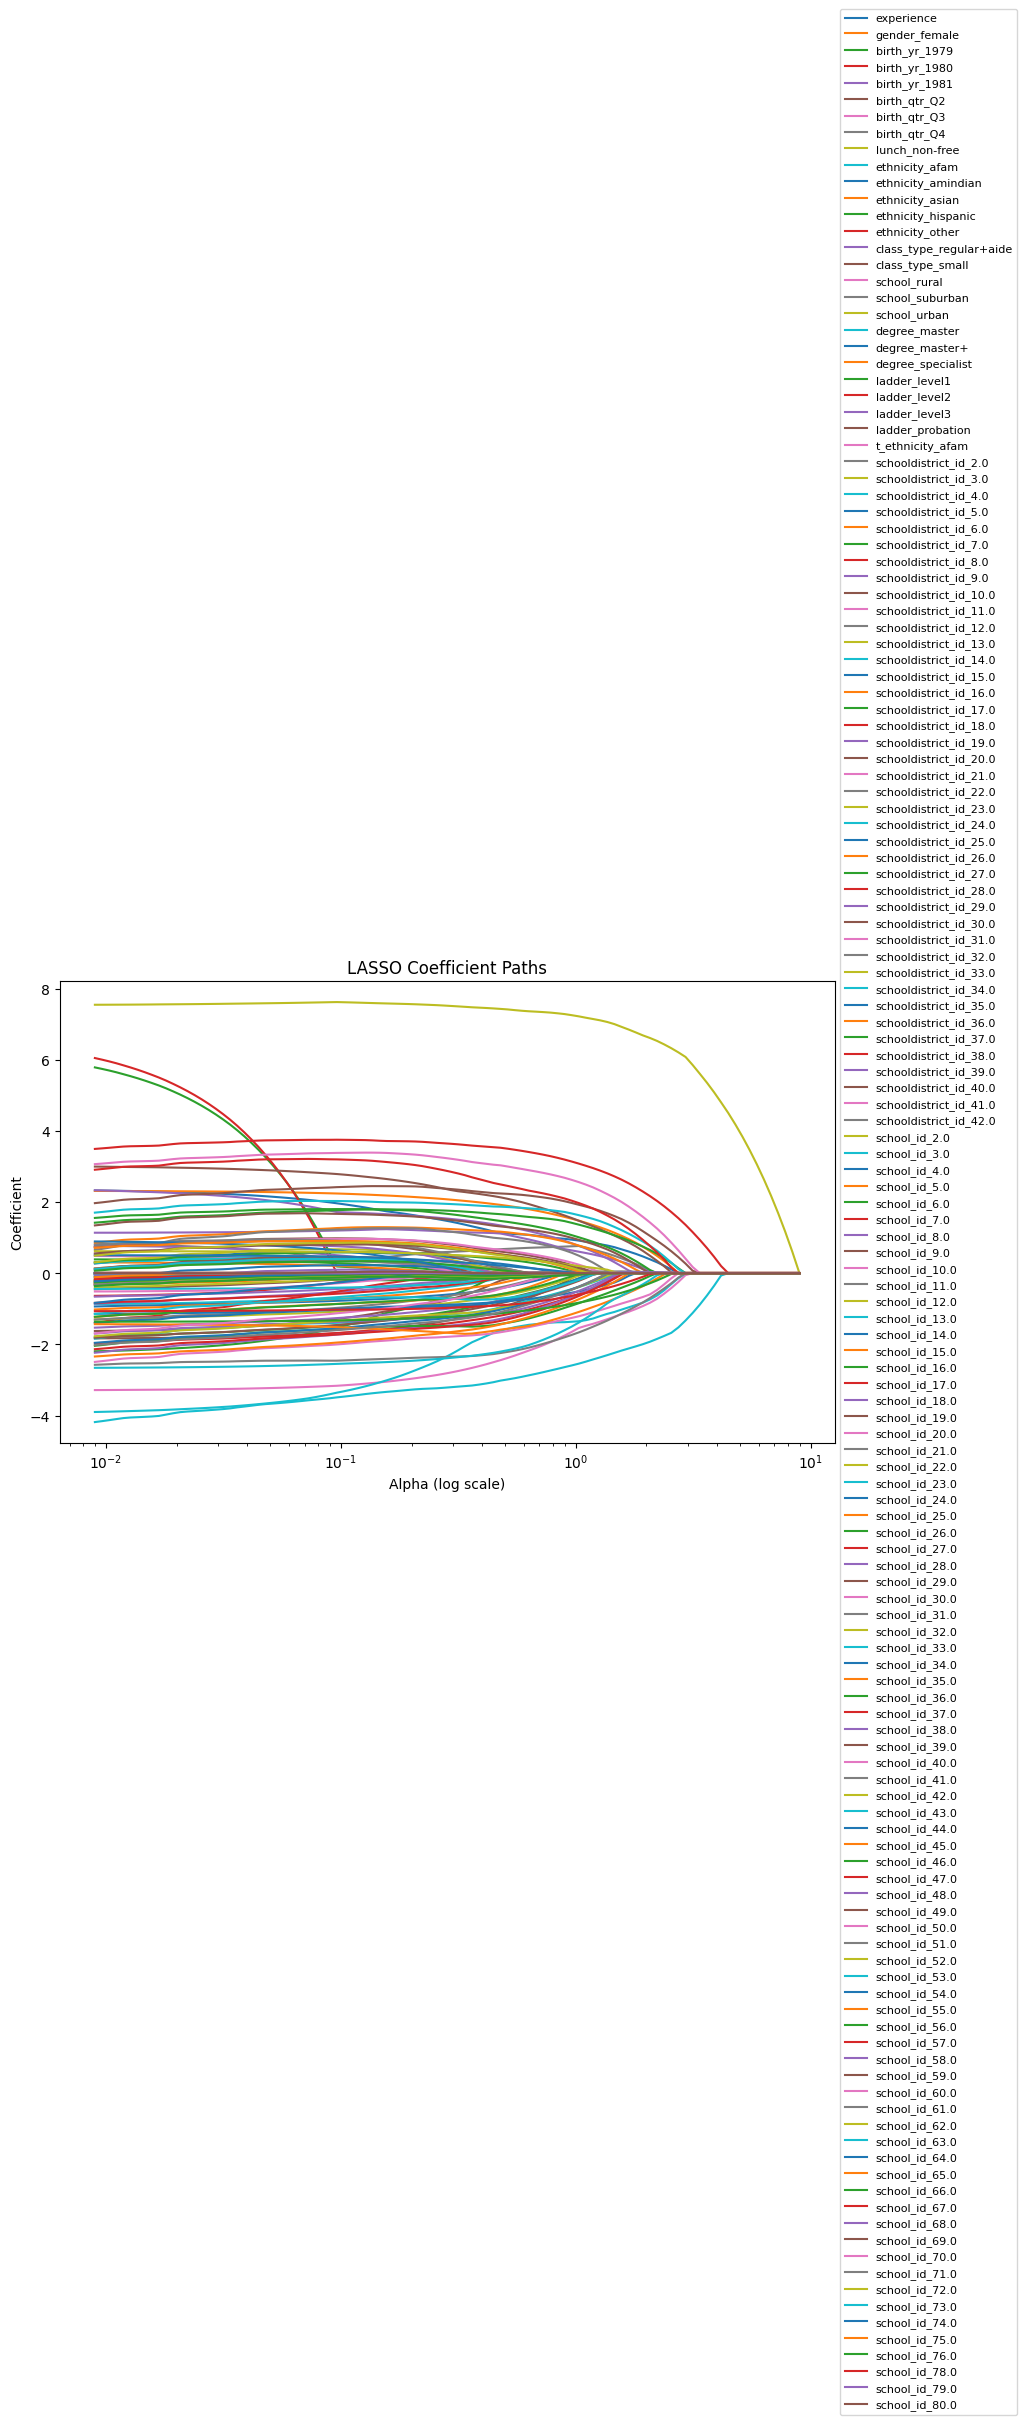

In [ ]:
# Compute LASSO path
alphas_lasso, coefs_lasso, _ = lasso_path(X_train_std, y_train)

plt.figure(figsize=(10, 6))
for i in range(coefs_lasso.shape[0]):
    plt.plot(alphas_lasso, coefs_lasso[i, :], label=X_train_std.columns[i])
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Coefficient')
plt.title('LASSO Coefficient Paths')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1, fontsize=8)
plt.show()

# 5. Ridge

In [ ]:
ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 100), store_cv_values=True)
ridge_cv.fit(X_train_std, y_train)
ridge_final = Ridge(alpha=ridge_cv.alpha_).fit(X_train_std, y_train)
y_test_pred_ridge = ridge_final.predict(X_test_std)
print(f"\nRidge Test MSE: {mean_squared_error(y_test, y_test_pred_ridge):.3f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(



Ridge Test MSE: 714.709


# 6. Elastic Net

In [ ]:
warnings.filterwarnings("ignore", message="Coordinate descent without L1 regularization")

elastic_cv = ElasticNetCV(
    l1_ratio=np.linspace(0.1, 1, 10),  # ← comma added here
    alphas=np.logspace(-3, 3, 100),
    cv=10,
    max_iter=10000,
    n_jobs=-1,
    random_state=42
)

elastic_cv.fit(X_train_std, y_train)
y_test_pred_en = elastic_cv.predict(X_test_std)

print(f"\nElastic Net Test MSE: {mean_squared_error(y_test, y_test_pred_en):.3f}")
print(f"Best alpha: {elastic_cv.alpha_:.4f}, Best L1 ratio: {elastic_cv.l1_ratio_:.2f}")


Elastic Net Test MSE: 714.534
Best alpha: 0.1000, Best L1 ratio: 0.10


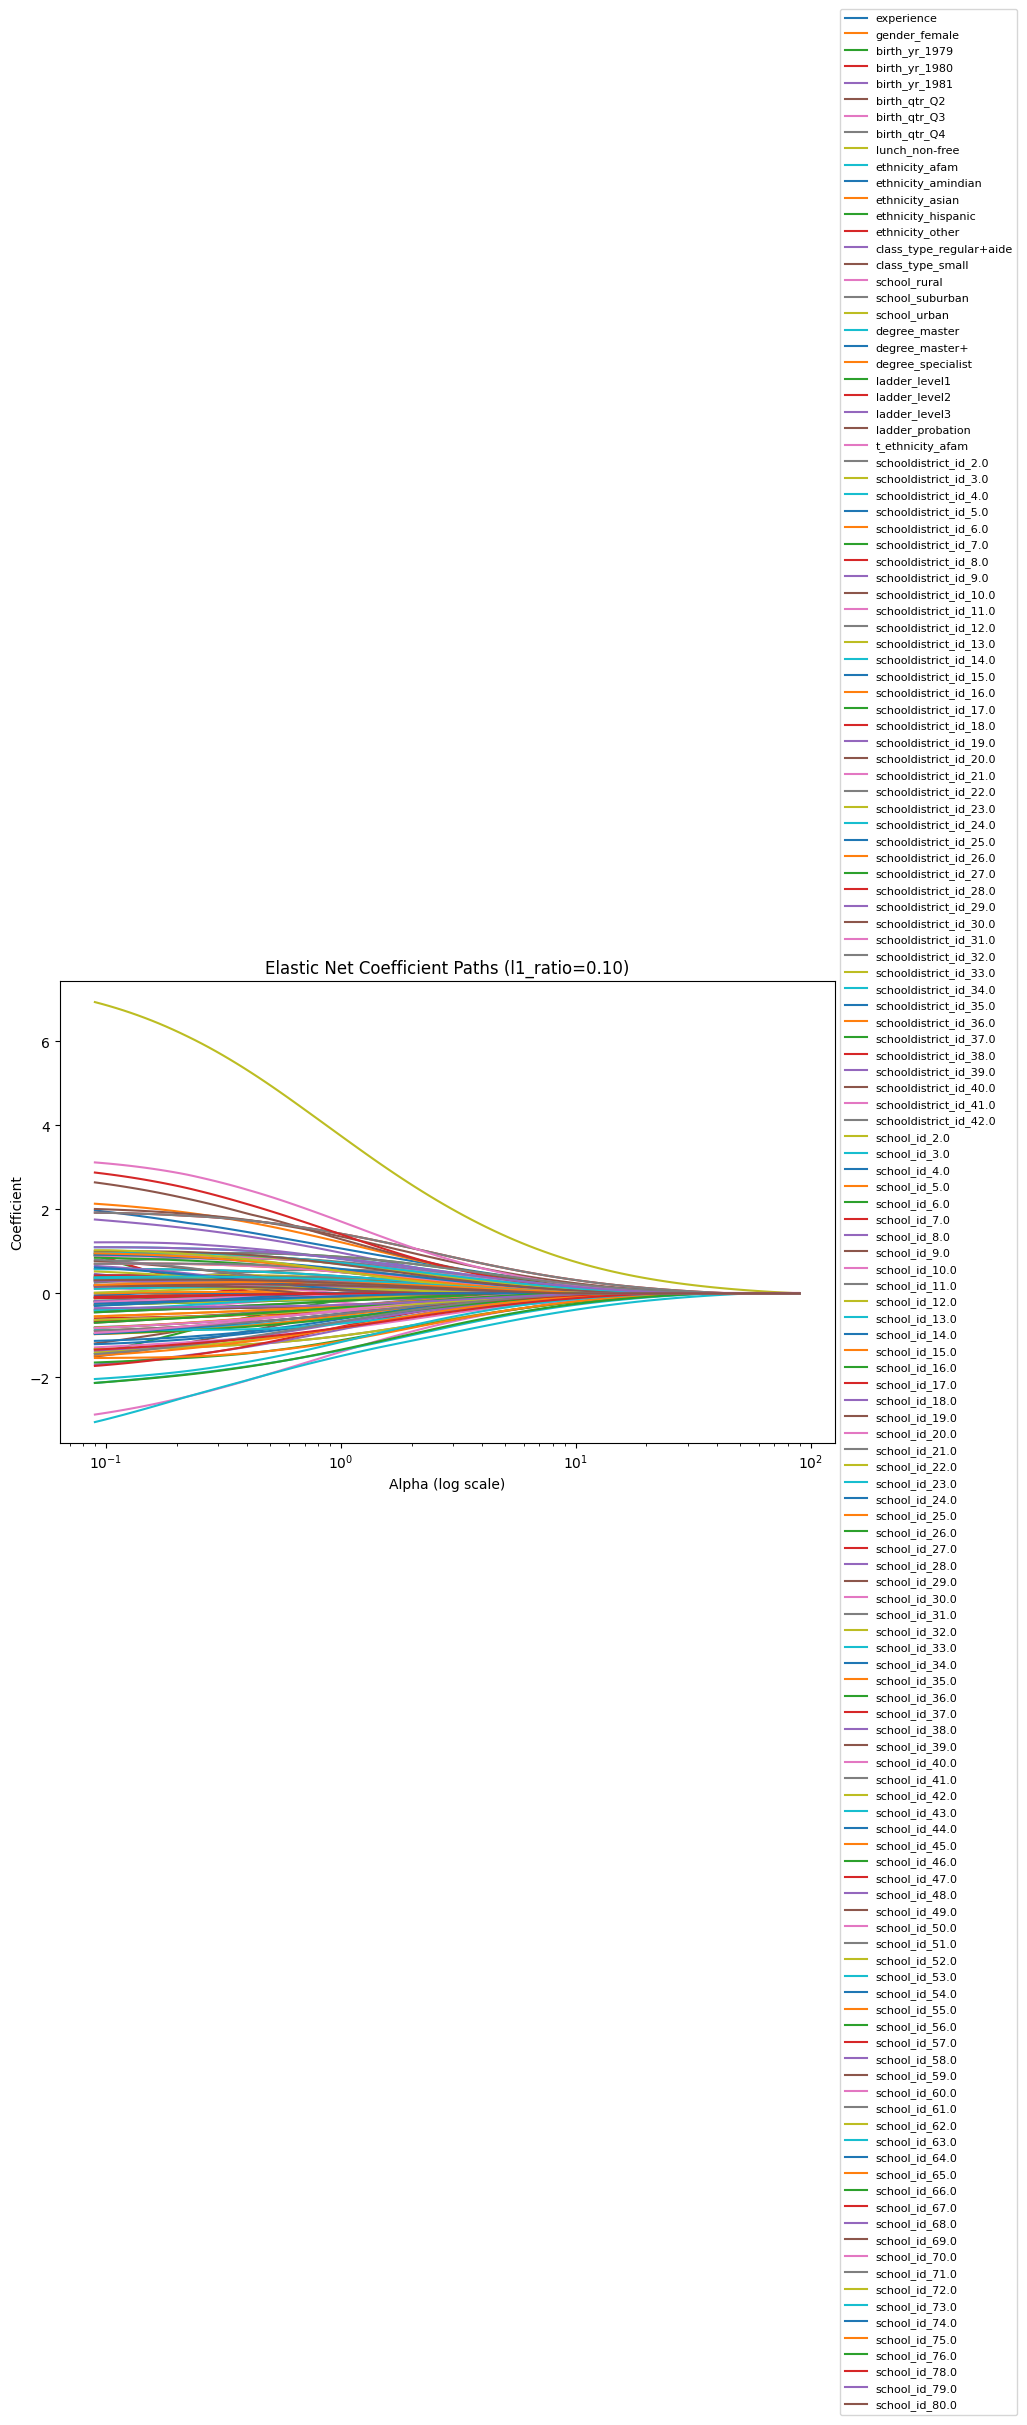

In [ ]:
# Use the best L1 ratio from Elastic Net
l1_ratio = elastic_cv.l1_ratio_

alphas_enet, coefs_enet, _ = enet_path(X_train_std, y_train, l1_ratio=l1_ratio)

plt.figure(figsize=(10, 6))
for i in range(coefs_enet.shape[0]):
    plt.plot(alphas_enet, coefs_enet[i, :], label=X_train_std.columns[i])
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Coefficient')
plt.title(f'Elastic Net Coefficient Paths (l1_ratio={l1_ratio:.2f})')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1, fontsize=8)
plt.show()

# 7. Model Comparison

In [ ]:
results = pd.DataFrame({
    "Model": ["OLS (Best Subset)", "LASSO", "Ridge", "Elastic Net"],
    "Best Alpha": [np.nan, lasso_cv.alpha_, ridge_cv.alpha_, elastic_cv.alpha_],
    "L1 Ratio": [np.nan, 1.0, 0.0, elastic_cv.l1_ratio_],
    "Test MSE": [
        ols_best_mse,
        mean_squared_error(y_test, lasso_final.predict(X_test_std)),
        mean_squared_error(y_test, ridge_final.predict(X_test_std)),
        mean_squared_error(y_test, elastic_cv.predict(X_test_std))
    ]
})

print("\nModel Comparison:\n", results)


Model Comparison:
                Model  Best Alpha  L1 Ratio    Test MSE
0  OLS (Best Subset)         NaN       NaN  715.336681
1              LASSO    0.167935       1.0  714.175217
2              Ridge  247.707636       0.0  714.709103
3        Elastic Net    0.100000       0.1  714.534073
